# EDA — Ocupación de listings (is_occupied)

**Dataset:** `project3grupo1.dbt_transform.mart_occupancy_features`  
**Target:** `is_occupied` (0 = libre, 1 = ocupado)

In [ ]:
# Conexión a BigQuery
from google.cloud import bigquery
client = bigquery.Client(project='project3grupo1')

In [ ]:
# Vista rápida de las primeras filas
query = """
SELECT * FROM `project3grupo1.dbt_transform.mart_occupancy_features`
LIMIT 5
"""

df = client.query(query).to_dataframe()
df.head()

/Users/marta/Documents/Máster/IADATA-PROJECT3/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,is_occupied,date,day_of_week,month,year,is_weekend,days_to_next_holiday,listing_id,neighbourhood_cleansed,room_type,...,temp_min,temp_mean,precipitation_mm,num_events,num_concerts,num_sports,num_festivals,max_attendance,total_attendance,is_holiday
0,0,2025-07-13,1,7,2025,1,33,1334002050175792624,el Barri Gòtic,Entire home/apt,...,18.3,22.7,0.0,0,0,0,0,0,0,0
1,0,2025-07-13,1,7,2025,1,33,1285736153466318287,Sant Antoni,Entire home/apt,...,18.3,22.7,0.0,0,0,0,0,0,0,0
2,0,2025-07-13,1,7,2025,1,33,1374549645942719771,"Sant Pere, Santa Caterina i la Ribera",Entire home/apt,...,18.3,22.7,0.0,0,0,0,0,0,0,0
3,0,2025-07-13,1,7,2025,1,33,40467518,el Barri Gòtic,Entire home/apt,...,18.3,22.7,0.0,0,0,0,0,0,0,0
4,0,2025-07-13,1,7,2025,1,33,1421086650720386956,la Nova Esquerra de l'Eixample,Entire home/apt,...,18.3,22.7,0.0,0,0,0,0,0,0,0


In [ ]:
# Dependencias
!pip install scipy statsmodels
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import datetime
from scipy.stats import chi2_contingency, kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Carga completa del dataset
query = """
SELECT * FROM `project3grupo1.dbt_transform.mart_occupancy_features`
"""

df = client.query(query).to_dataframe()
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

/Users/marta/Documents/Máster/IADATA-PROJECT3/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset cargado: 4,336,555 filas × 34 columnas


In [ ]:
# Inspección inicial y duplicados
TARGET = 'is_occupied'

print('=== SHAPE ===')
print(df.shape)

print('\n=== INFO ===')
df.info()

print('\n=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')

print('\n=== VALORES ÚNICOS POR COLUMNA ===')
nunique = df.nunique().sort_values()
print(nunique)

# Columnas constantes (nunique == 1) aportan cero información
constantes = nunique[nunique == 1].index.tolist()
print(f'\nColumnas constantes: {constantes}')

# Posibles IDs en columnas object (nunique ~ n_filas)
cat_cols_all = df.select_dtypes(include='object').columns
posibles_ids = [c for c in cat_cols_all if df[c].nunique() > len(df) * 0.9]
print(f'Posibles IDs en categóricas: {posibles_ids}')

print('\n=== NULOS ===')
nulos = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct.round(2)})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('%', ascending=False)
print(resumen_nulos if len(resumen_nulos) > 0 else 'Sin nulos')

=== SHAPE ===
(4336555, 34)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4336555 entries, 0 to 4336554
Data columns (total 34 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   is_occupied                Int64  
 1   date                       dbdate 
 2   day_of_week                Int64  
 3   month                      Int64  
 4   year                       Int64  
 5   is_weekend                 Int64  
 6   days_to_next_holiday       Int64  
 7   listing_id                 Int64  
 8   neighbourhood_cleansed     object 
 9   room_type                  object 
 10  accommodates               Int64  
 11  bedrooms                   float64
 12  beds                       float64
 13  listing_price              float64
 14  minimum_nights             Int64  
 15  number_of_reviews          Int64  
 16  review_scores_rating       float64
 17  review_scores_cleanliness  float64
 18  review_scores_location     float64
 19  

In [ ]:
# Investigar duplicados 
dupes = df.duplicated(subset=['listing_id', 'date']).sum()
print(f'Duplicados por listing_id + date: {dupes:,}')

Duplicados por listing_id + date: 1,009,062


In [13]:
# Cogemos los grupos con más de una fila para el mismo listing + date
dupes_mask = df.duplicated(subset=['listing_id', 'date'], keep=False)
df_dupes = df[dupes_mask].sort_values(['listing_id', 'date'])

# Para cada columna, cuántos grupos tienen valores distintos dentro del par
print('Columnas que varían dentro de listing_id + date:')
for col in df.columns:
    if col in ['listing_id', 'date']:
        continue
    n_variable = df_dupes.groupby(['listing_id', 'date'])[col].nunique()
    n_conflictos = (n_variable > 1).sum()
    if n_conflictos > 0:
        print(f'  {col}: {n_conflictos:,} grupos con valores distintos')

Columnas que varían dentro de listing_id + date:
  is_occupied: 256,976 grupos con valores distintos


In [ ]:
# Vemos combinaciones de los duplicados
conflictos = (
    df.groupby(['listing_id', 'date'])['is_occupied']
    .agg(list)
    .apply(sorted)
    .value_counts()
)
print('\nCombinaciones de is_occupied dentro del mismo listing + date:')
print(conflictos.head(10))


Combinaciones de is_occupied dentro del mismo listing + date:
is_occupied
[0]       1426710
[1]        891721
[0, 0]     529816
[0, 1]     256976
[1, 1]     222270
Name: count, dtype: int64


El problema viene de la tabla `calendar` de Inside Airbnb: contiene múltiples
*snapshots* del mismo listing en la misma fecha. La tabla `listings_dedup`
deduplica listings, pero `calendar` no está deduplicada.

**Solución:** aplicar `QUALIFY ROW_NUMBER()` directamente sobre
`mart_occupancy_features` al momento de la carga.

In [ ]:
# Corregimos la query
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
QUALIFY ROW_NUMBER() OVER (PARTITION BY listing_id, date ORDER BY date DESC) = 1
"""

df = client.query(query).to_dataframe()
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

/Users/marta/Documents/Máster/IADATA-PROJECT3/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset cargado: 3,327,493 filas × 34 columnas


In [ ]:
# Verificamos que ya no hay duplicados y revisamos el estado de los nulos
TARGET = 'is_occupied'

print('=== SHAPE ===')
print(df.shape)

print('\n=== DUPLICADOS (verificación) ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Duplicados por listing_id + date: {df.duplicated(subset=["listing_id", "date"]).sum()}')

print('\n=== VALORES ÚNICOS POR COLUMNA ===')
print(df.nunique().sort_values())

print('\n=== NULOS ===')
nulos = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct.round(2)})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('%', ascending=False)
print(resumen_nulos if len(resumen_nulos) > 0 else 'Sin nulos')

=== SHAPE ===
(3327493, 34)

=== DUPLICADOS (verificación) ===
Filas duplicadas: 0
Duplicados por listing_id + date: 0

=== VALORES ÚNICOS POR COLUMNA ===
is_occupied                      2
instant_bookable                 2
is_weekend                       2
year                             2
is_holiday                       2
num_sports                       4
room_type                        4
num_festivals                    5
day_of_week                      7
num_concerts                    12
month                           12
num_events                      15
accommodates                    16
max_attendance                  17
total_attendance                19
bedrooms                        20
beds                            28
minimum_nights                  61
neighbourhood_cleansed          69
precipitation_mm                76
days_to_next_holiday            87
review_scores_location         136
review_scores_rating           151
temp_mean                      158
revie

El conteo de nulos en las columnas de temperatura coincide exactamente con
el número de listings únicos, lo que sugiere que falta *una fecha completa*
en los datos meteorológicos.

In [19]:
# ¿Cuántas fechas distintas tienen nulos en temp_max?
fechas_sin_meteo = df[df['temp_max'].isnull()]['date'].nunique()
print(f'Fechas sin datos meteorológicos: {fechas_sin_meteo}')

# ¿Cuántos listings hay en esas fechas?
listings_en_esas_fechas = df[df['temp_max'].isnull()]['listing_id'].nunique()
print(f'Listings afectados: {listings_en_esas_fechas}')

Fechas sin datos meteorológicos: 1
Listings afectados: 12273


Identificamos la fecha concreta.

In [ ]:
# Miramos qué fecha es
fecha_sin_meteo = df[df['temp_max'].isnull()]['date'].unique()
print(f'Fecha sin datos meteorológicos: {fecha_sin_meteo}')

Fecha sin datos meteorológicos: <DateArray>
[]
Length: 0, dtype: dbdate


Es el 15 de mayo, quitamos los registros de esa fecha del dataset.

In [22]:
import datetime
df = df[df['date'] != datetime.date(2026, 5, 15)]
print(f'Shape tras eliminar fecha sin meteo: {df.shape[0]:,} filas')

Shape tras eliminar fecha sin meteo: 3,315,220 filas


Nos centramos en el resto de nulos.

In [23]:
nulos = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, '%': nulos_pct.round(2)})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('%', ascending=False)
print(resumen_nulos if len(resumen_nulos) > 0 else 'Sin nulos')

                            nulos      %
review_scores_cleanliness  629129  18.98
review_scores_rating       628887  18.97
review_scores_location     628887  18.97
review_scores_value        628887  18.97
beds                        16584   0.50
bedrooms                     3719   0.11


Como los nulos están por debajo del 20% los imputaremos de forma simple, por mediana.

=== BALANCE DEL TARGET ===
is_occupied
0    2077306
1    1237914
Name: count, dtype: Int64

is_occupied
0    62.66
1    37.34
Name: proportion, dtype: Float64

Ratio max/min: 1.68
Tipo: Binaria


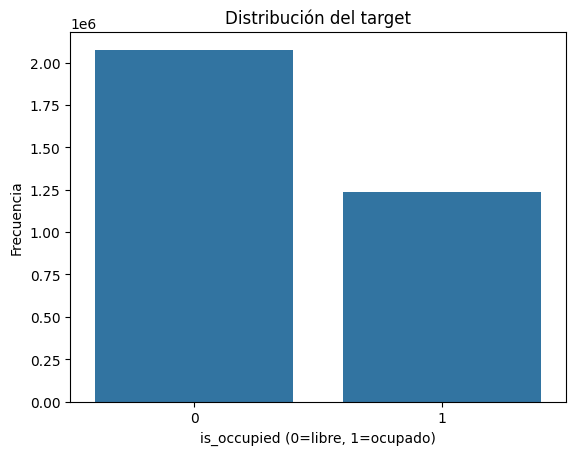

In [30]:
print('=== BALANCE DEL TARGET ===')
counts = df[TARGET].value_counts().sort_index()
pcts = df[TARGET].value_counts(normalize=True).sort_index() * 100

print(counts)
print()
print(pcts.round(2))

ratio = counts.max() / counts.min()
print(f'\nRatio max/min: {ratio:.2f}')

n_classes = df[TARGET].nunique()
is_binary = n_classes == 2
print(f'Tipo: {"Binaria" if is_binary else f"Multiclase ({n_classes} clases)"}')

sns.countplot(x=TARGET, data=df)
plt.title('Distribución del target')
plt.xlabel('is_occupied (0=libre, 1=ocupado)')
plt.ylabel('Frecuencia')
plt.show()

El desbalanceo es **moderado** (ratio ≈ 1.68) y no va a sesgar el modelo.
Se puede entrenar sin `class_weight='balanced'` en principio; conviene
monitorizar el F1 por clase durante la evaluación.

Usamos **Kruskal-Wallis** (no paramétrico) para medir si la distribución
de cada feature difiere según la clase. Con 3.3 M de filas todos los
p-valores son 0.0000, así que el **estadístico H** es la medida de fuerza.

Columnas numéricas a analizar: ['day_of_week', 'month', 'year', 'is_weekend', 'days_to_next_holiday', 'accommodates', 'bedrooms', 'beds', 'listing_price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'temp_max', 'temp_min', 'temp_mean', 'precipitation_mm', 'num_events', 'num_concerts', 'num_sports', 'num_festivals', 'max_attendance', 'total_attendance', 'is_holiday']


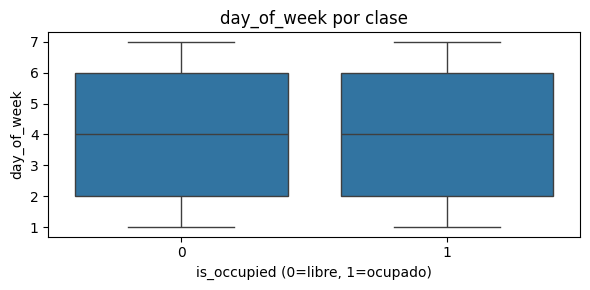

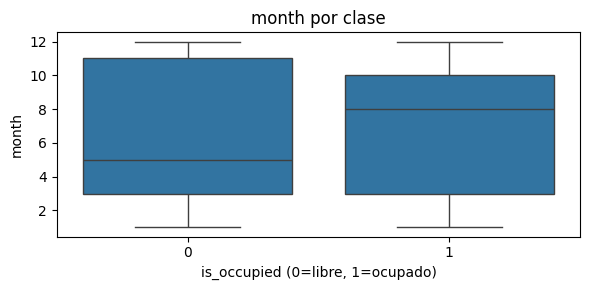

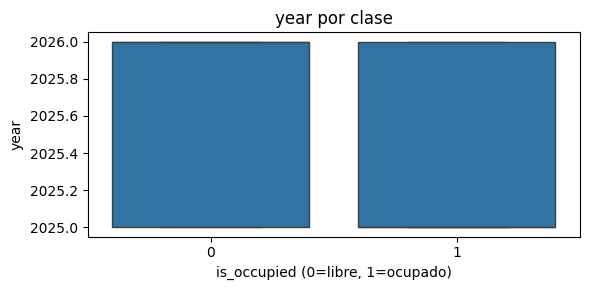

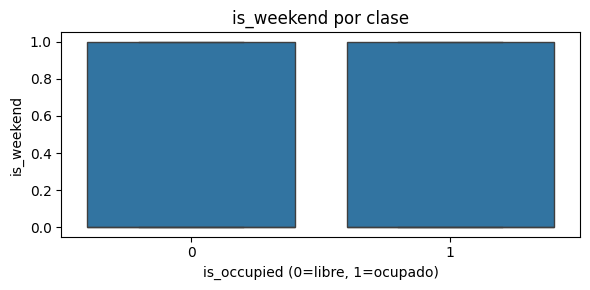

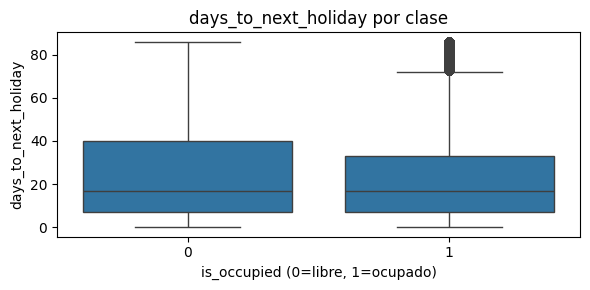

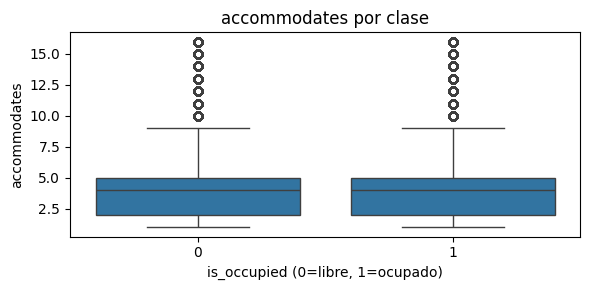

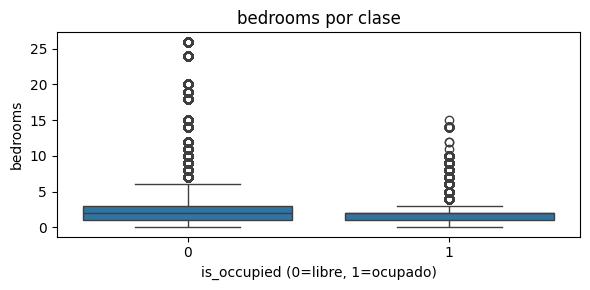

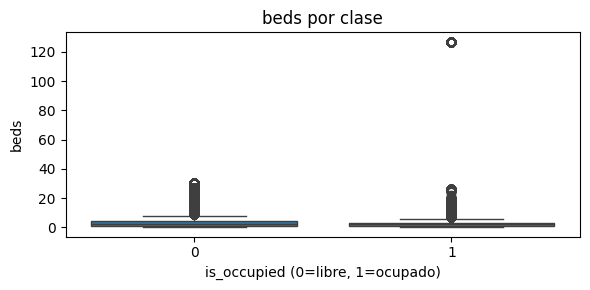

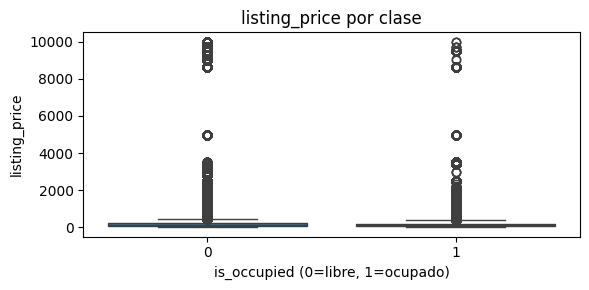

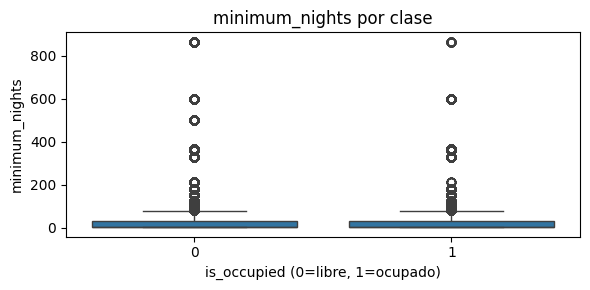

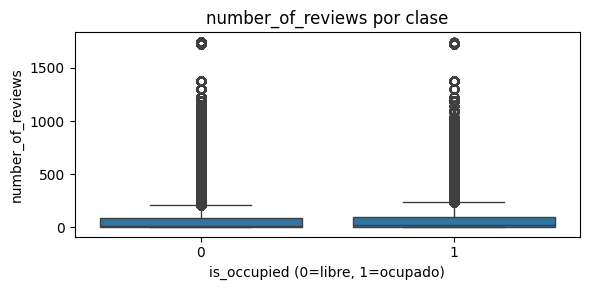

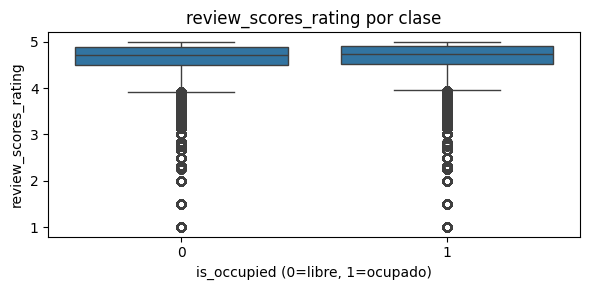

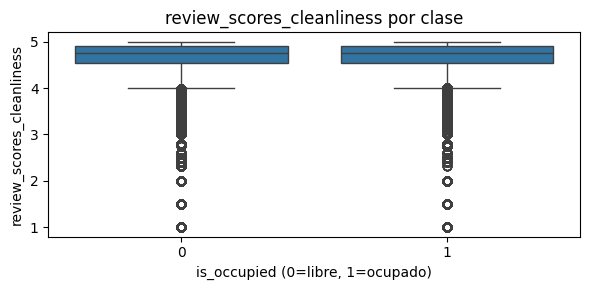

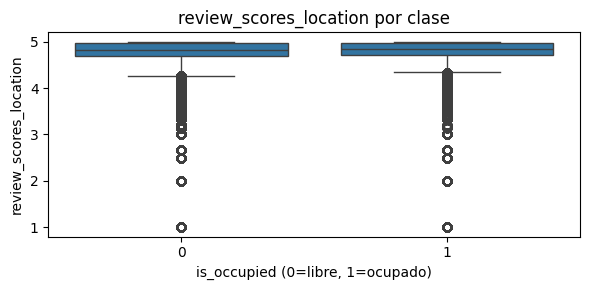

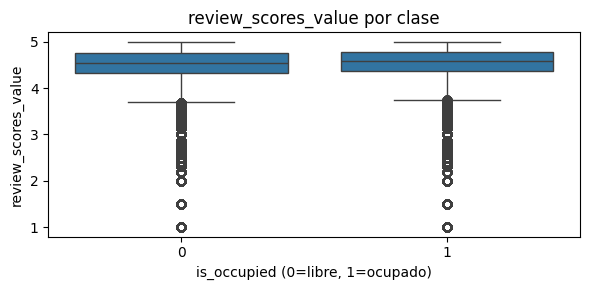

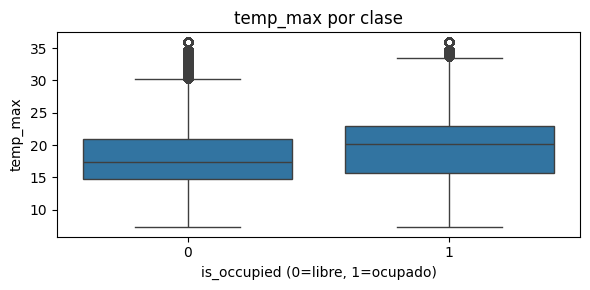

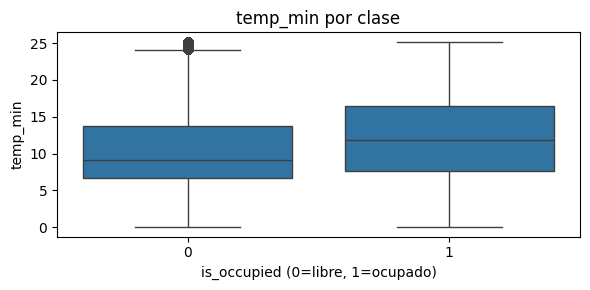

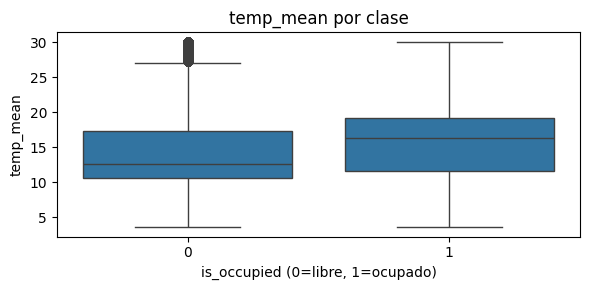

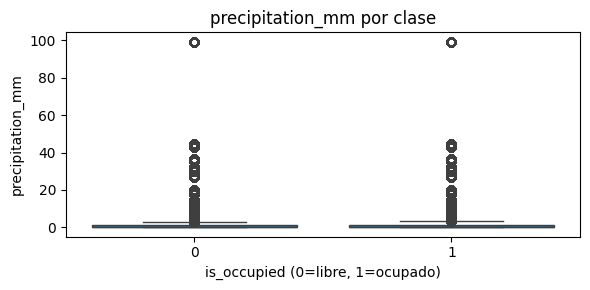

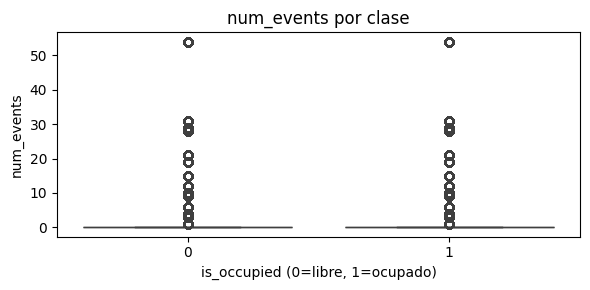

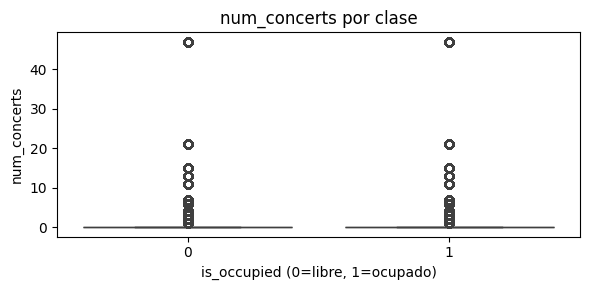

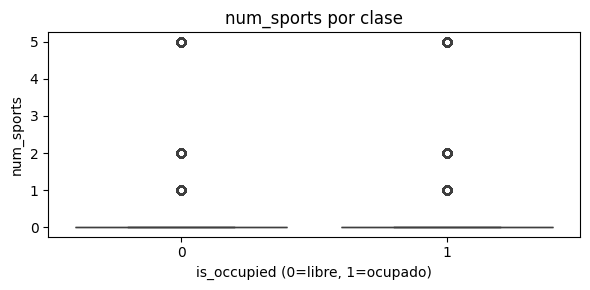

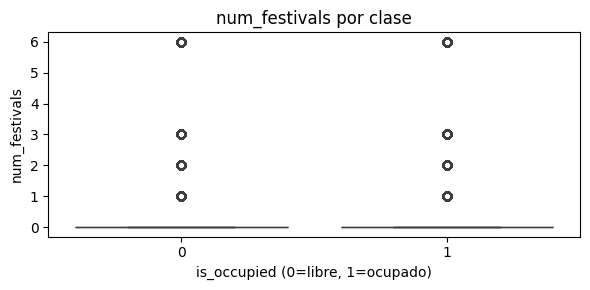

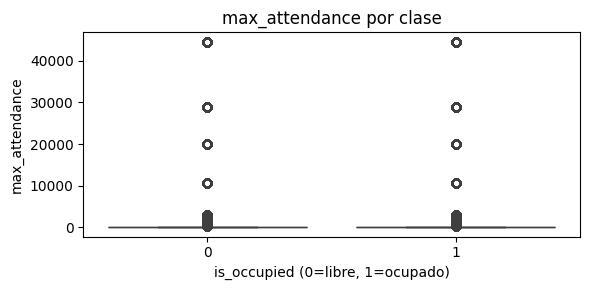

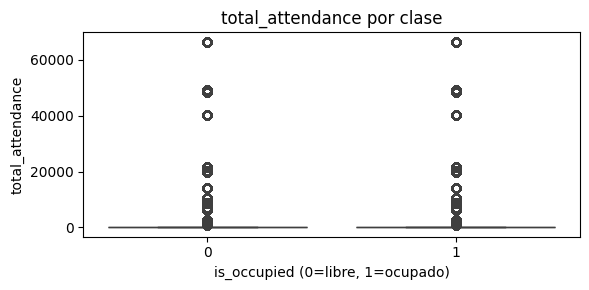

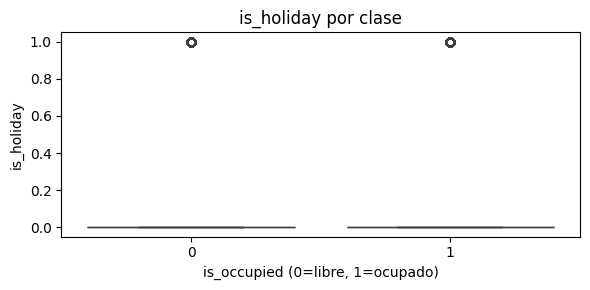


Kruskal-Wallis (numéricas vs target):
  ✓ day_of_week: H=373.54  p=0.0000
  ✓ month: H=13224.47  p=0.0000
  ✓ year: H=59087.37  p=0.0000
  ✓ is_weekend: H=31.22  p=0.0000
  ✓ days_to_next_holiday: H=880.58  p=0.0000
  ✓ accommodates: H=2099.93  p=0.0000
  ✓ bedrooms: H=251.55  p=0.0000
  ✓ beds: H=1267.23  p=0.0000
  ✓ listing_price: H=14618.44  p=0.0000
  ✓ minimum_nights: H=3599.09  p=0.0000
  ✓ number_of_reviews: H=4573.99  p=0.0000
  ✓ review_scores_rating: H=3279.48  p=0.0000
  ✓ review_scores_cleanliness: H=288.31  p=0.0000
  ✓ review_scores_location: H=3014.51  p=0.0000
  ✓ review_scores_value: H=6057.15  p=0.0000
  ✓ temp_max: H=110698.37  p=0.0000
  ✓ temp_min: H=110687.75  p=0.0000
  ✓ temp_mean: H=116175.68  p=0.0000
  ✓ precipitation_mm: H=1197.26  p=0.0000
  ✓ num_events: H=3538.02  p=0.0000
  ✓ num_concerts: H=2969.63  p=0.0000
  ✓ num_sports: H=819.90  p=0.0000
  ✓ num_festivals: H=945.72  p=0.0000
  ✓ max_attendance: H=3516.14  p=0.0000
  ✓ total_attendance: H=3511.24 

In [31]:
# Excluimos columnas que no son features: IDs, fecha, coordenadas
EXCLUDE = ['listing_id', 'date', 'latitude', 'longitude']

num_cols = df.select_dtypes(include=np.number).columns
num_cols = [c for c in num_cols if c != TARGET and c not in EXCLUDE]

print(f'Columnas numéricas a analizar: {num_cols}')

# Boxplots por clase
for col in num_cols:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax)
    ax.set_title(f'{col} por clase')
    ax.set_xlabel('is_occupied (0=libre, 1=ocupado)')
    plt.tight_layout()
    plt.show()

# Kruskal-Wallis
print('\nKruskal-Wallis (numéricas vs target):')
for col in num_cols:
    groups = [df.loc[df[TARGET] == c, col].dropna().values for c in df[TARGET].unique()]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = '✓' if p < 0.05 else '✗'
        print(f'  {sig} {col}: H={stat:.2f}  p={p:.4f}')

| Feature | H | |
|---|---|---|
| `temp_mean` / `temp_max` / `temp_min` | ~110.000–116.000 | 🔴 Muy alta — redundantes entre sí, confirmar con VIF |
| `year` | 59.087 | 🔴 Solo 2 años, puede ser artefacto temporal |
| `listing_price` | 14.618 | 🟠 Alta |
| `month` | 13.224 | 🟠 Alta — estacionalidad relevante |
| `review_scores_value` / `number_of_reviews` | 4.000–6.000 | 🟠 Alta — reputación del listing importa |
| `minimum_nights` / `num_events` / `num_concerts` | 2.000–3.600 | 🟡 Moderada |
| `days_to_next_holiday` / `is_holiday` / `day_of_week` | 373–880 | 🟢 Baja |
| `bedrooms` / `review_scores_cleanliness` / `is_weekend` | 31–288 | 🟢 Muy baja |

Usamos **Cramér's V** (normaliza el chi² por tamaño muestral) para medir
la asociación entre cada categórica y el target.

Columnas categóricas: ['neighbourhood_cleansed', 'room_type']

Cramér's V (categóricas vs target):


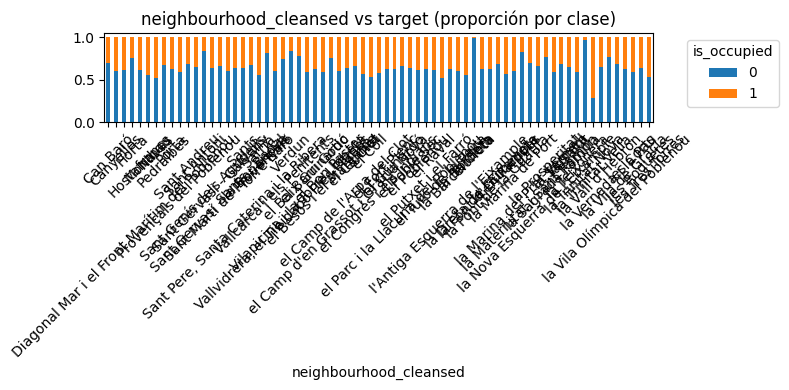

  neighbourhood_cleansed: V=0.065  chi2=13856.63  p=0.0000


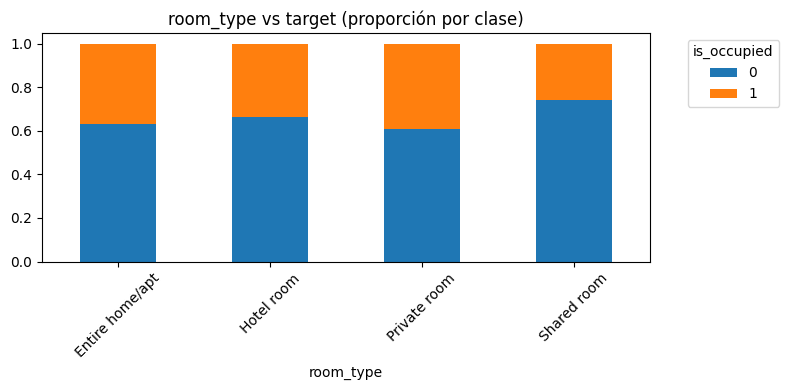

  room_type: V=0.028  chi2=2646.06  p=0.0000


In [33]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Columnas categóricas: {cat_cols}')

def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print('\nCramér\'s V (categóricas vs target):')
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET])
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(f'{col} vs target (proporción por clase)')
    plt.xticks(rotation=45)
    plt.legend(title='is_occupied', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    v = cramers_v(df[col].dropna(), df.loc[df[col].notna(), TARGET])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f'  {col}: V={v:.3f}  chi2={chi2:.2f}  p={p:.4f}')

Ambas salen significativas (p=0.0000) por el tamaño del dataset, pero la V confirma 
que ni el barrio ni el tipo de habitación discriminan apenas la ocupación por sí solos.

Se mantienen en el modelo — pueden capturar interacciones con otras features — 
pero no se esperan como features importantes.

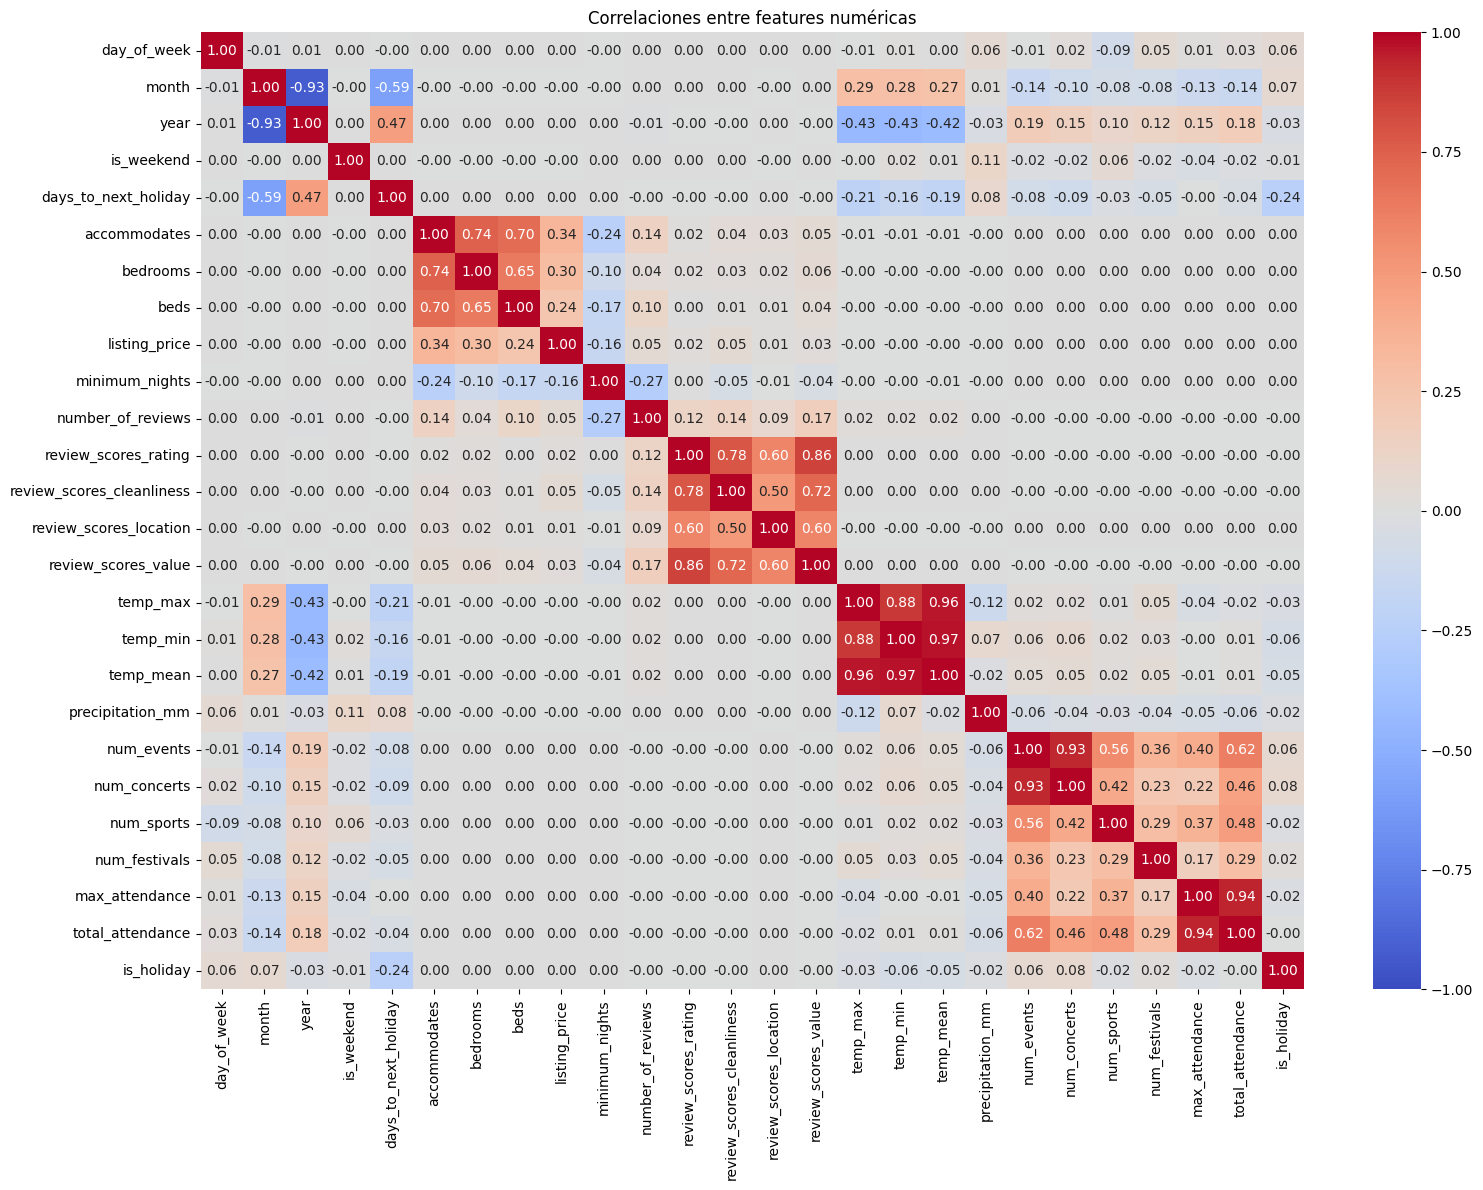

                  feature         VIF
                temp_mean 1785.808294
                 temp_max  723.443325
     review_scores_rating  539.414508
                 temp_min  355.955169
      review_scores_value  331.741374
   review_scores_location  322.434738
review_scores_cleanliness  306.104806
                     year  267.152480
         total_attendance   30.511076
           max_attendance   23.560304
               num_events   18.516648
             accommodates   17.266713
             num_concerts   13.943395
                 bedrooms   13.164414
                     beds    9.870692
                    month    7.916998
              day_of_week    5.238552
     days_to_next_holiday    4.232570
               num_sports    1.784417
        number_of_reviews    1.580048
            listing_price    1.457345
            num_festivals    1.454041
               is_weekend    1.450217
           minimum_nights    1.448786
         precipitation_mm    1.387690
            

In [36]:
# Heatmap de correlaciones entre numéricas
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1)
plt.title('Correlaciones entre features numéricas')
plt.tight_layout()
plt.show()

# VIF
X_vif = df[num_cols].dropna().astype(float)
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

| Eliminar | Mantener | Motivo |
|---|---|---|
| `temp_max`, `temp_min` | `temp_mean` | VIF > 350; las tres miden lo mismo |
| `review_scores_value`, `review_scores_location`, `review_scores_cleanliness` | `review_scores_rating` | VIF > 300; resumen suficiente |
| `year` | — | VIF = 267; artefacto temporal correlacionado con meses y temperaturas |
| `max_attendance`, `num_events`, `num_concerts` | `total_attendance` | Redundancia parcial |
| `bedrooms`, `beds` | `accommodates` | Correlacionados entre sí |
| `latitude`, `longitude` | `neighbourhood_cleansed` | IDs geográficos |
| `listing_id`, `date` | — | IDs, no son features |

Features con VIF bajo que se mantienen todas: `num_sports`, `number_of_reviews`,
`listing_price`, `num_festivals`, `is_weekend`, `minimum_nights`,
`precipitation_mm`, `is_holiday`.

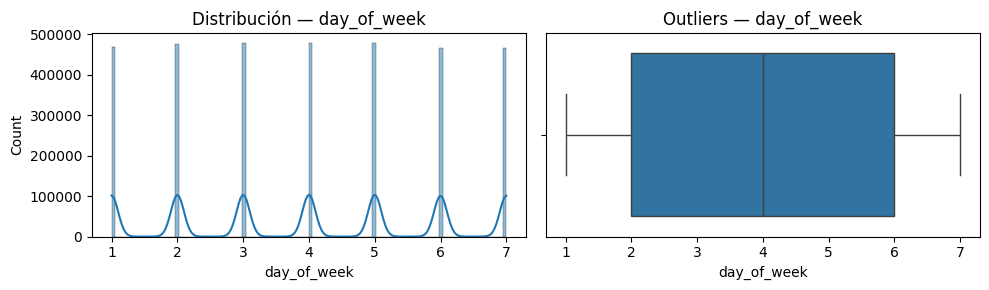

day_of_week: 0 outliers (0.0%)


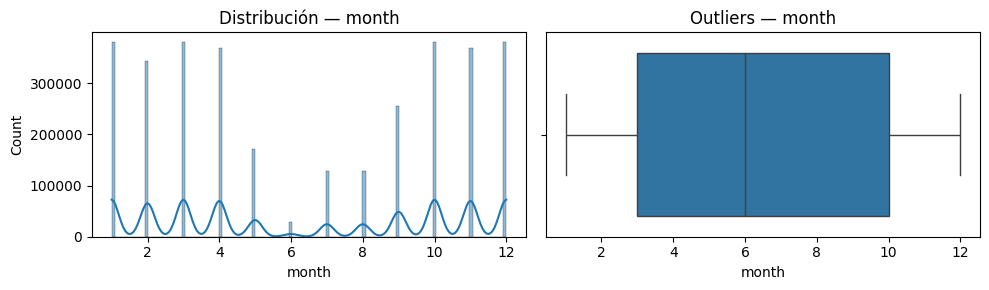

month: 0 outliers (0.0%)


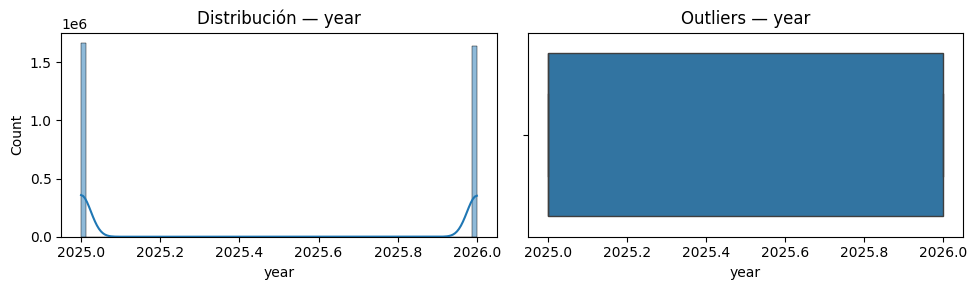

year: 0 outliers (0.0%)


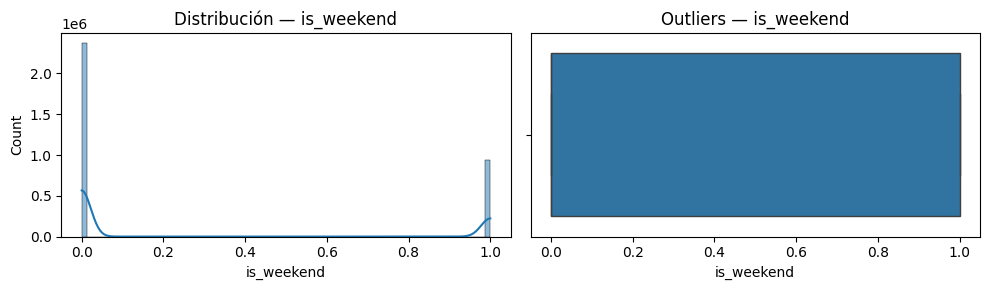

is_weekend: 0 outliers (0.0%)


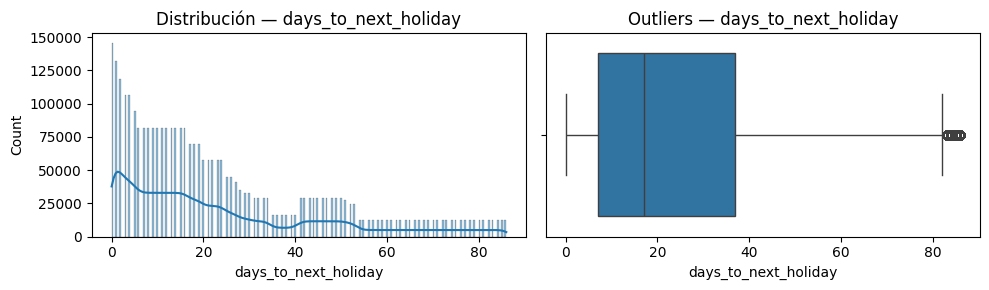

days_to_next_holiday: 49,092 outliers (1.5%)


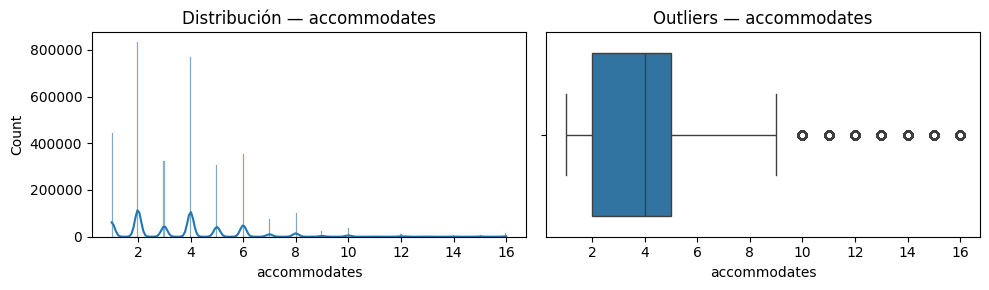

accommodates: 85,753 outliers (2.6%)


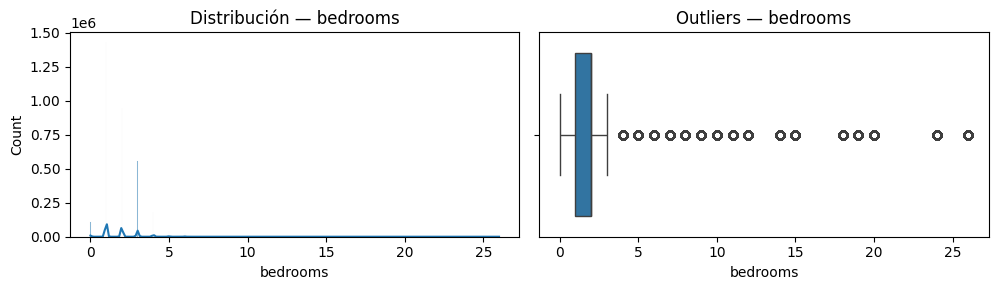

bedrooms: 272,516 outliers (8.2%)


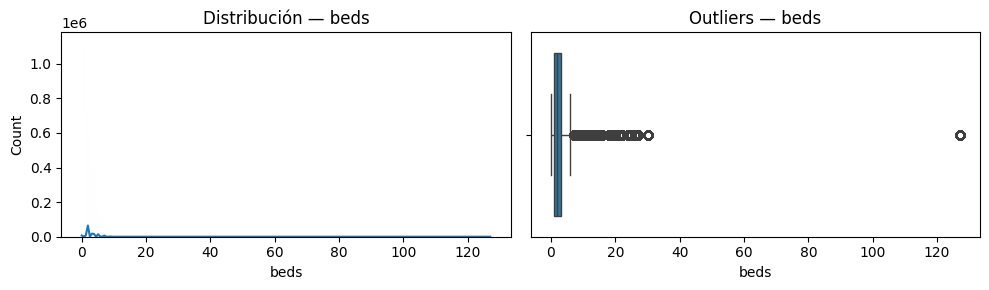

beds: 130,108 outliers (3.9%)


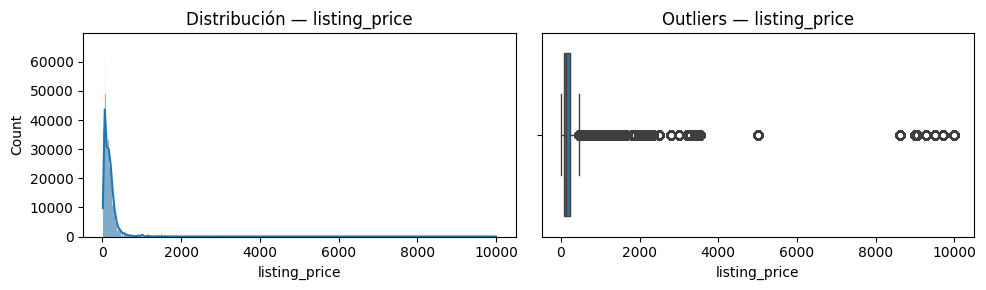

listing_price: 152,596 outliers (4.6%)


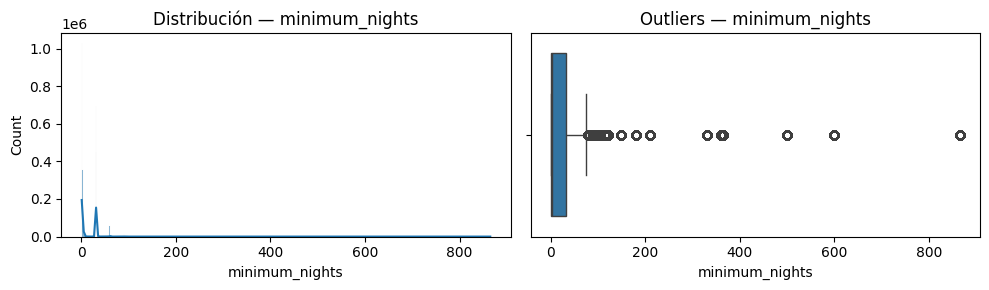

minimum_nights: 30,689 outliers (0.9%)


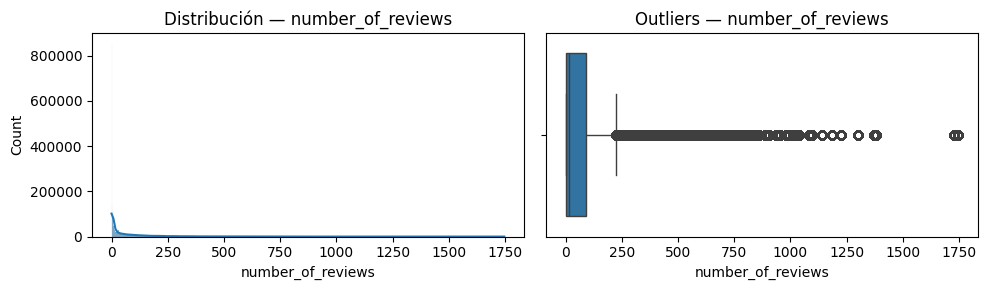

number_of_reviews: 328,268 outliers (9.9%)


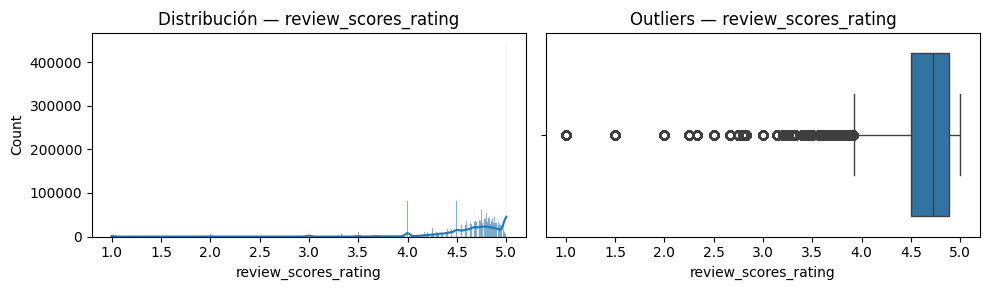

review_scores_rating: 100,926 outliers (3.0%)


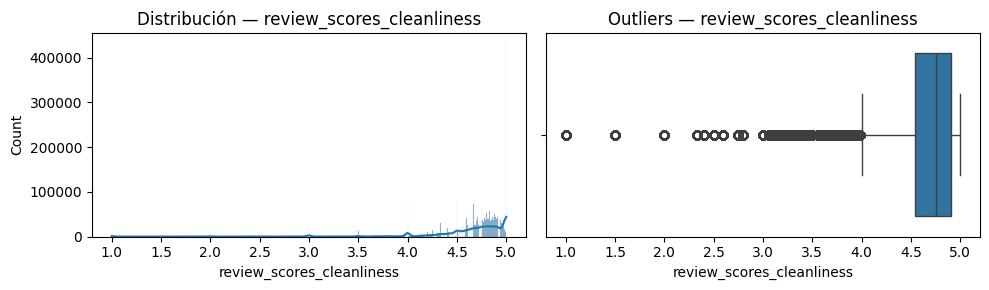

review_scores_cleanliness: 114,768 outliers (3.5%)


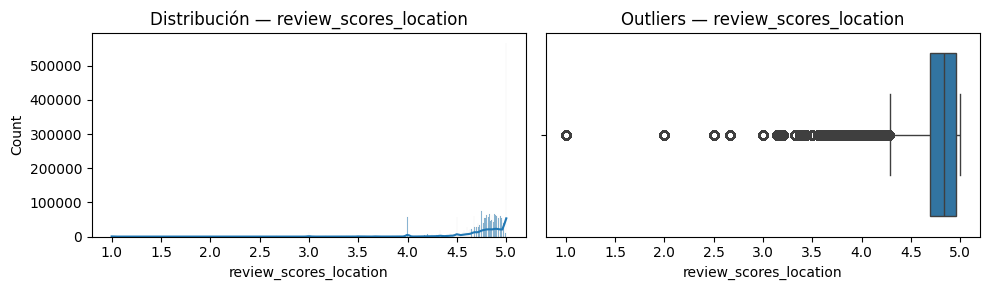

review_scores_location: 151,140 outliers (4.6%)


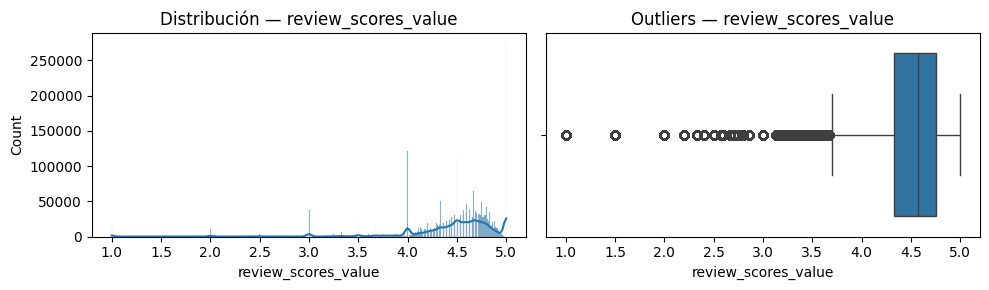

review_scores_value: 140,814 outliers (4.2%)


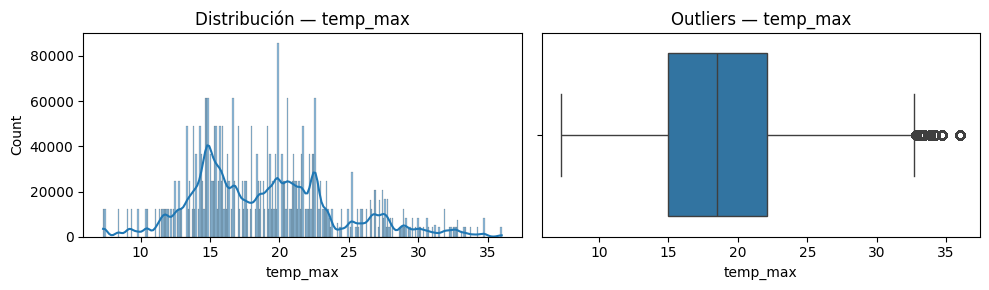

temp_max: 39,255 outliers (1.2%)


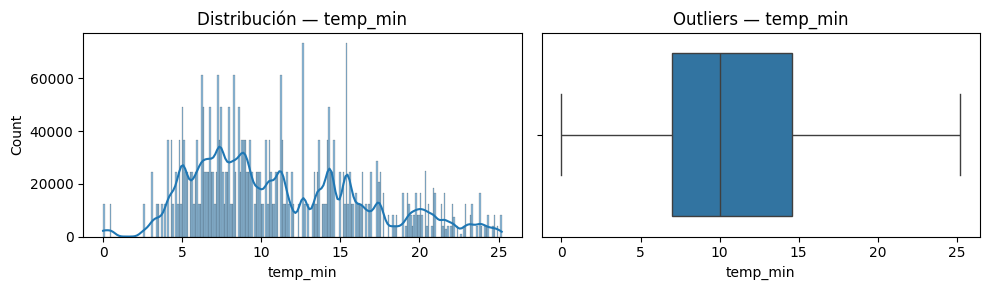

temp_min: 0 outliers (0.0%)


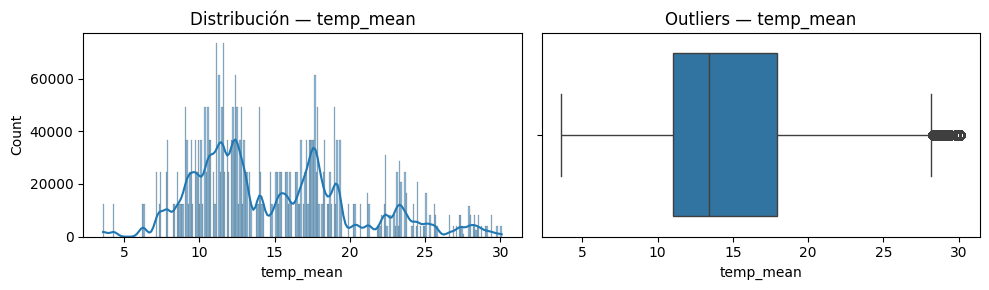

temp_mean: 52,511 outliers (1.6%)


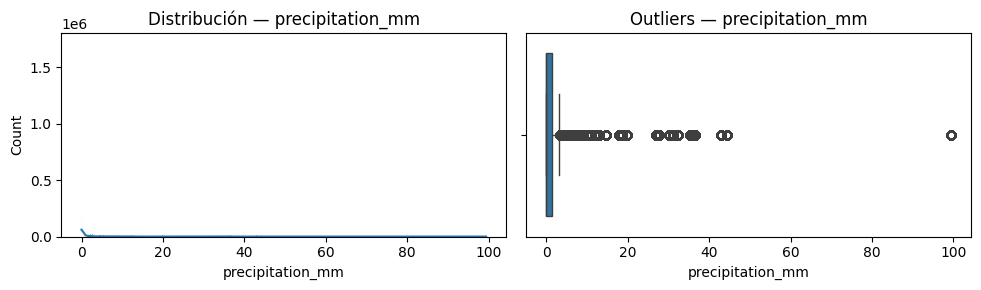

precipitation_mm: 512,002 outliers (15.4%)


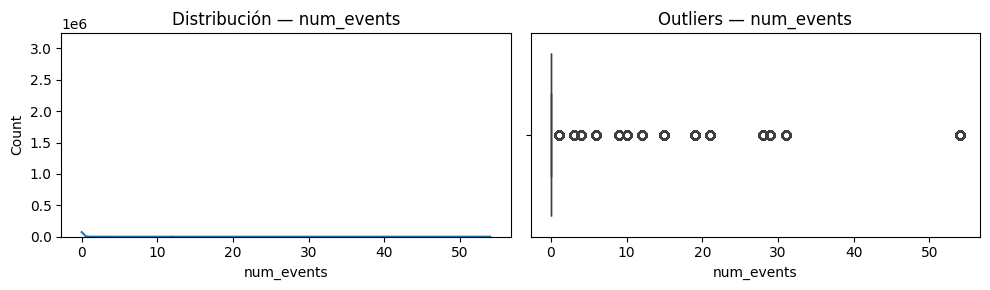

num_events: 220,914 outliers (6.7%)


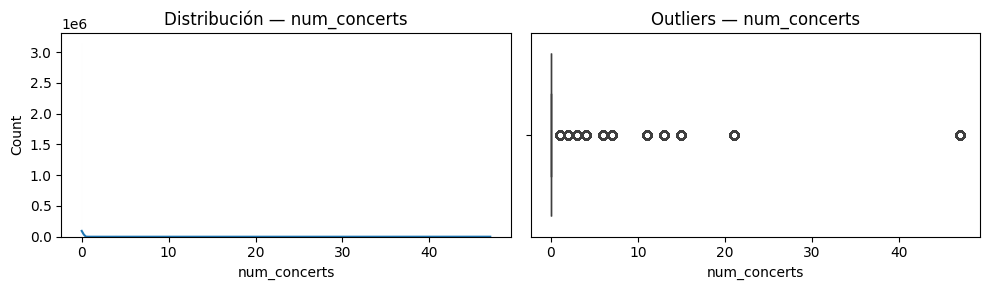

num_concerts: 159,549 outliers (4.8%)


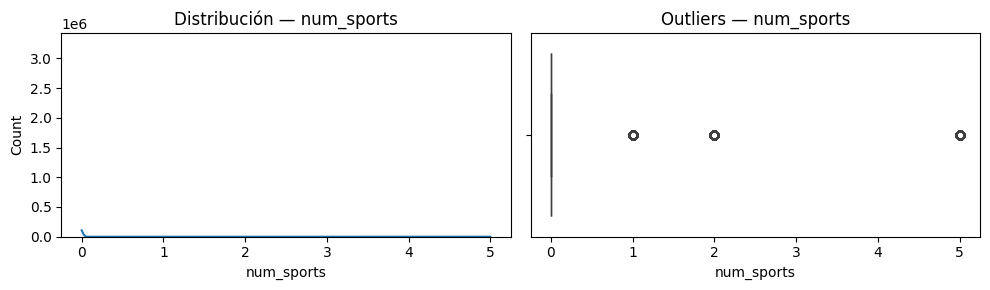

num_sports: 49,092 outliers (1.5%)


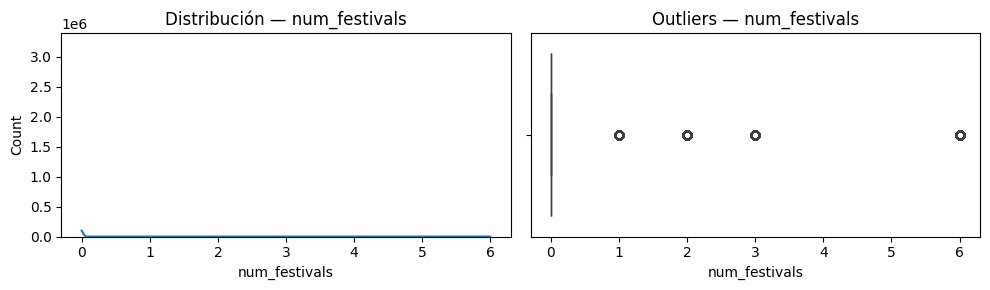

num_festivals: 73,638 outliers (2.2%)


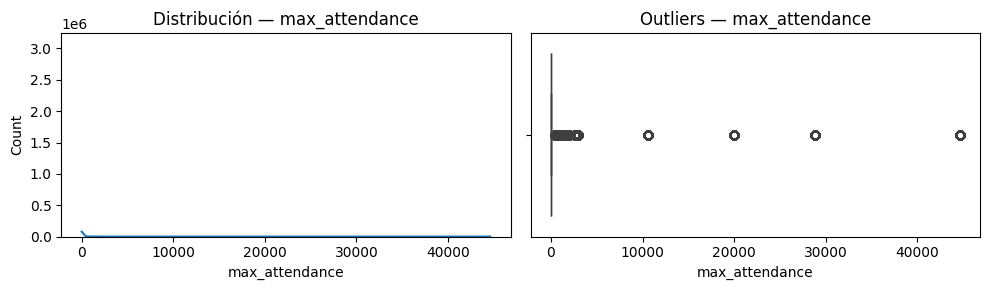

max_attendance: 220,914 outliers (6.7%)


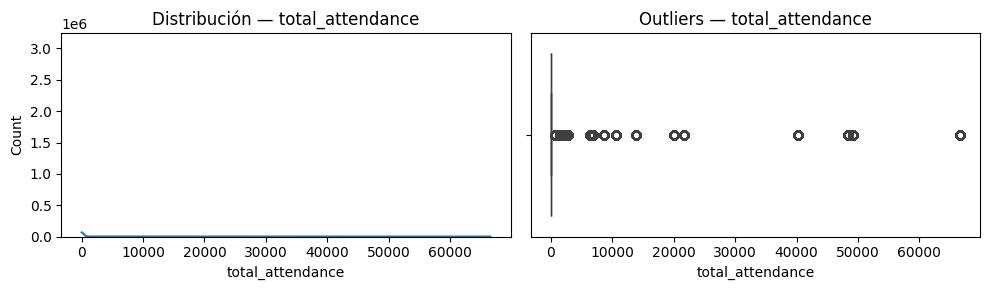

total_attendance: 220,914 outliers (6.7%)


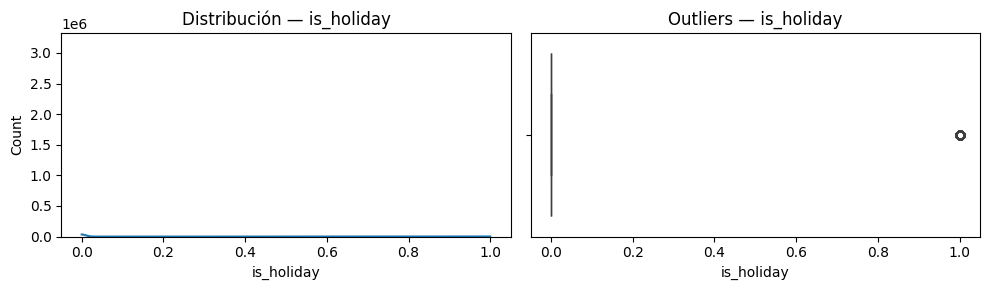

is_holiday: 146,034 outliers (4.4%)


In [38]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    # Histograma
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución — {col}')
    
    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Outliers — {col}')
    
    plt.tight_layout()
    plt.show()
    
    # Conteo de outliers IQR
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {n_out:,} outliers ({n_out/len(df)*100:.1f}%)')

| Feature | Outliers | % | Nota |
|---|---|---|---|
| `precipitation_mm` | 512.002 | 15.4% | 🔴 Días con lluvia intensa — distribución muy asimétrica, muchos ceros |
| `number_of_reviews` | 328.268 | 9.9% | 🔴 Listings muy populares con reviews muy altos |
| `bedrooms` | 272.516 | 8.2% | 🟠 Pisos grandes fuera del rango típico |
| `num_events` / `max_attendance` / `total_attendance` | 220.914 | 6.7% | 🟠 Días con muchos eventos — ya candidatos a eliminar por VIF |
| `num_concerts` | 159.549 | 4.8% | 🟠 |
| `listing_price` | 152.596 | 4.6% | 🟠 Pisos de lujo con precios muy altos |
| `review_scores_location` | 151.140 | 4.6% | 🟠 |
| `review_scores_value` | 140.814 | 4.2% | 🟠 |
| `beds` | 130.108 | 3.9% | 🟠 |
| `review_scores_cleanliness` | 114.768 | 3.5% | 🟠 |
| `review_scores_rating` | 100.926 | 3.0% | 🟠 |
| `accommodates` | 85.753 | 2.6% | 🟡 |
| `num_festivals` | 73.638 | 2.2% | 🟡 |
| `temp_mean` / `temp_max` | ~40-52k | 1.2-1.6% | 🟡 |
| `days_to_next_holiday` / `num_sports` / `minimum_nights` | ~30-49k | 0.9-1.5% | 🟢 |
| Temporales, `temp_min` | 0 | 0% | ✅ Sin outliers |

In [39]:
for col in ['bedrooms', 'listing_price']:
    print(f'\n=== {col} ===')
    print(df[col].describe())
    print(f'\nTop 10 valores más altos:')
    print(df[col].value_counts().sort_index(ascending=False).head(10))


=== bedrooms ===
count    3.311501e+06
mean     1.911056e+00
std      1.336152e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      2.600000e+01
Name: bedrooms, dtype: float64

Top 10 valores más altos:
bedrooms
26.0     326
24.0     484
20.0     484
19.0     242
18.0     242
15.0     727
14.0     485
12.0    2106
11.0     242
10.0    4040
Name: count, dtype: int64

=== listing_price ===
count    3.315220e+06
mean     1.912281e+02
std      3.458424e+02
min      9.000000e+00
25%      7.300000e+01
50%      1.440000e+02
75%      2.250000e+02
max      1.000000e+04
Name: listing_price, dtype: float64

Top 10 valores más altos:
listing_price
10000.0    243
9999.0     242
9715.0     325
9500.0     324
9286.0     242
9059.0     968
9000.0     243
8613.0     325
5000.0     325
4999.0     242
Name: count, dtype: int64


In [40]:
for col in ['bedrooms', 'listing_price']:
    p99 = df[col].quantile(0.99)
    p01 = df[col].quantile(0.01)
    n_afectados = ((df[col] > p99) | (df[col] < p01)).sum()
    print(f'{col}: p01={p01:.1f}  p99={p99:.1f}  → {n_afectados:,} filas afectadas')

bedrooms: p01=0.0  p99=6.0  → 28,731 filas afectadas
listing_price: p01=23.0  p99=1000.0  → 64,356 filas afectadas


Se aplica **cap por percentil 99** únicamente en dos features:
- **`bedrooms`** (p99 = 6): valores > 6 probablemente corresponden a hoteles
  o errores de entrada.
- **`listing_price`** (p99 = 1 000 €): valores superiores son precios
  bloqueados o incorrectos, no reflejan precios reales de mercado.

Para el **resto de features no se aplica cap**: los outliers representan
variabilidad real del dominio (días de tormenta, listings populares, eventos
masivos) y contienen señal útil. Además, los modelos tree-based son robustos
a outliers en los valores de las features.

## Recap EDA 

### Dataset
- **3 315 220 filas × 34 columnas** tras limpiar
- Clasificación **binaria**: 62.66 % libre (0) · 37.34 % ocupado (1)
- Ratio max/min = 1.68 → equilibrado, no necesita resampling

---

### Problemas encontrados y resueltos

| Problema | Solución |
|---|---|
| ~1 M duplicados en `listing_id + date` | `QUALIFY ROW_NUMBER()` sobre `mart_occupancy_features` |
| Fecha 15/05/2026 sin datos meteorológicos | Eliminada del dataset |
| `instant_bookable` de tipo boolean | Convertir a `int` en preprocesamiento |
| `date` de tipo `dbdate` | Excluir del modelo (ya descompuesta en otras features) |

---

### Nulos

| Columna | % nulos | Decisión |
|---|---|---|
| `review_scores_*` (4 columnas) | ~19 % | Imputar mediana |
| `beds` | 0.50 % | Imputar mediana |
| `bedrooms` | 0.11 % | Imputar mediana |

---

### Features numéricas → target (Kruskal-Wallis H)

| Feature | H | |
|---|---|---|
| `temp_mean` / `temp_max` / `temp_min` | ~110 k–116 k | 🔴 Muy alta — redundantes entre sí |
| `year` | 59 k | 🔴 Posible artefacto temporal |
| `listing_price` / `month` | 13 k–14 k | 🟠 Alta |
| `review_scores_value` / `number_of_reviews` | 4 k–6 k | 🟠 Alta |
| `minimum_nights` / eventos | 2 k–3.6 k | 🟡 Moderada |
| `day_of_week` / festivos | 373–880 | 🟢 Baja |
| `bedrooms` / `is_weekend` | 31–288 | 🟢 Muy baja |

---

### Features categóricas → target (Cramér's V)

| Feature | V | |
|---|---|---|
| `neighbourhood_cleansed` | 0.065 | Asociación muy débil |
| `room_type` | 0.028 | Asociación muy débil |

Se mantienen — pueden capturar interacciones con otras features.

---

### Multicolinealidad (VIF)

| Eliminar | Mantener | Motivo |
|---|---|---|
| `temp_max`, `temp_min` | `temp_mean` | Redundantes |
| `review_scores_value`, `_location`, `_cleanliness` | `review_scores_rating` | Redundantes |
| `year` | — | Artefacto temporal + VIF = 267 |
| `max_attendance`, `num_events`, `num_concerts` | `total_attendance` | Redundantes |
| `bedrooms`, `beds` | `accommodates` | Correlacionados entre sí |
| `latitude`, `longitude` | `neighbourhood_cleansed` | IDs geográficos |
| `listing_id`, `date` | — | IDs, no son features |

---

### Outliers

| Feature | Tratamiento |
|---|---|
| `bedrooms` | Cap p99 = 6 (valores > 6 → hoteles o errores) |
| `listing_price` | Cap p99 = 1 000 € (precios bloqueados / incorrectos) |
| Resto | Sin cap — variabilidad real del dominio |

---

### Features finales para el modelo

34 columnas originales → **18 features** tras eliminar IDs, redundantes
y artefactos temporales:

```
month, day_of_week, is_weekend, days_to_next_holiday, is_holiday,
neighbourhood_cleansed, room_type, accommodates, listing_price,
minimum_nights, number_of_reviews, review_scores_rating,
instant_bookable, temp_mean, precipitation_mm,
num_sports, num_festivals, total_attendance
```
